# Notebook 25 — 5-PFT box + per-PFT K_Fe (Track 1 v2.2.1)

**Goal.** Recover all 6 Carroll-6 parameters at calibration-grade quality (≤ 40% off Carroll's published Green's-functions optima). nb23 (v2.2 with shared K_FE) reached 3/6; this notebook tests whether per-PFT iron half-saturations push that to 4–6/6.

**Hypothesis (from nb23 result).** nb23's biggest regression was `alpfe` going from 1% off Carroll (v2.0 nb20) to 89% off. The likely cause: shared K_FE across all 5 PFTs forces Pro-HL (47% biomass, low-Fe specialist) and diatoms (30% biomass, high-Fe demand) to share one half-saturation. The estimator compensates by skewing `alpfe` (iron dust solubility) into a region that satisfies the shared-K_FE compromise but not Carroll's optimum. Per-PFT K_FE breaks that aliasing.

**Change from nb23.** Single-line: pass `k_fe_per_pft=K_FE_VEC_PERFT` to `carroll6_5pft_integrate`. Everything else identical.

| Param | nb23 (shared K_FE) | nb25 expectation |
|---|---|---|
| alpfe | 0.891 (Loose, regressed from v2.0) | ↓ toward calibration-grade |
| scav_rat | 0.300 (Cal-grade) | stay or improve |
| Smallgrow | 1.244 (Drifted) | possible improvement |
| Biggrow | 0.326 (Cal-grade) | stay |
| diatomgraz | 0.282 (Cal-grade) | stay |
| R_PICPOC | 0.738 (Loose) | possible improvement |

**Note on K_FE values.** Per-PFT values in `carroll6_5pft.py` are literature-plausible orders of magnitude (Pro-HL 5 nM → diatoms 100 nM), not verified Darwin 3 v05 namelist values. v2.2.1 tests the **principle** that per-PFT differentiation helps; v2.2.2 can refine to Darwin-exact values once the `data.traits` file is accessible.

**Network: DINN baseline only.** Per the `feedback_drop_dinndeep_phase2plus` rule, DINNDeep saturates trivially and isn't informative about Carroll-grade recovery — drop it from v2.2.x onwards. ~35 min training wall-clock instead of ~70.

**Success criterion.** All 6 parameters in Calibration-grade band (≤ 40% off Carroll) or better.


In [1]:
import os
import sys
import time
import warnings
from pathlib import Path

# Quiet the xmitgcm available_diagnostics.log warning (cosmetic; values fine).
warnings.filterwarnings("once", category=UserWarning, module="xmitgcm")

_SRC = Path.cwd() / "src"
if _SRC.exists() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import matplotlib.pyplot as plt
import numpy as np
import torch

from darwindiff.carbonate import PCO2_ATM_DEFAULT, co2_flux, solve_carbonate
from darwindiff.carroll6 import (
    CARROLL_VALUES,
    H_MLD,
    PARAM_BOUNDS,
    PARAM_NAMES,
    bounded_params,
)
from darwindiff.carroll6_5pft import (
    I_ALK, I_DFE, I_DIATOM, I_DIC, I_LGE, I_PIC, I_POC, I_PROHL, I_PROLL, I_SYN,
    K_FE_VEC_PERFT,
    N_TRACERS,
    carroll6_5pft_integrate,
)
from darwindiff.diagnostics import format_pearson, safe_pearson_r
from darwindiff.ecco_darwin_loader import (
    EQUATORIAL_PACIFIC_AOI,
    open_bin_average,
    subset_aoi,
    time_mean,
)
from darwindiff.llc270_loader import bin_native_tracer_to_1deg
from darwindiff.networks import DINN

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

AOI = EQUATORIAL_PACIFIC_AOI
print(f"AOI: {AOI.name} ({AOI.lat_min}-{AOI.lat_max} N, {AOI.lon_min}-{AOI.lon_max} E)")
print(f"\nPer-PFT K_FE (v2.2.1, literature-plausible):")
labels = ["diatom", "lge_euk", "Syn", "Pro-LL", "Pro-HL"]
for label, kfe in zip(labels, K_FE_VEC_PERFT):
    print(f"  {label:<8s}: {kfe:.2e} mmol Fe / m^3  ({kfe*1e6:.1f} nM)")


Device: cuda
GPU: NVIDIA GeForce RTX 5090 Laptop GPU
AOI: Equatorial Pacific (-5.0-15.0 N, -160.0--110.0 E)

Per-PFT K_FE (v2.2.1, literature-plausible):
  diatom  : 1.00e-04 mmol Fe / m^3  (100.0 nM)
  lge_euk : 6.00e-05 mmol Fe / m^3  (60.0 nM)
  Syn     : 3.00e-05 mmol Fe / m^3  (30.0 nM)
  Pro-LL  : 1.00e-05 mmol Fe / m^3  (10.0 nM)
  Pro-HL  : 5.00e-06 mmol Fe / m^3  (5.0 nM)


## 1. Load Eq Pacific climatology — 11 Darwin targets + covariates

Identical to nb23. Per-PFT Chl + carbonate-flux + covariates from `bin_average`. FeT/POC/PIC/DIC/ALK from LLC270 native binned to 1°.


In [2]:
DATA_ROOT = Path(os.environ.get("DARWIN_DATA_ROOT", r"D:\\ecco_darwin_v5"))
BIN_AVG_PATH = str(DATA_ROOT / "bin_average" / "v05_ECCO-Darwin_bin_average_1x1_deg.nc")
MONTHLY_ROOT = str(DATA_ROOT / "output" / "monthly")
GRID_DIR = str(DATA_ROOT / "grid")

ds_bin = open_bin_average(BIN_AVG_PATH)
eqpac_clim = time_mean(subset_aoi(ds_bin, AOI))

sst = eqpac_clim.SST.values.astype(np.float64)
mld = eqpac_clim.mldDepth.values.astype(np.float64)
wind = eqpac_clim.windSpeed.values.astype(np.float64)
sss = eqpac_clim.SSS.values.astype(np.float64)
co2_flux_obs = eqpac_clim.CO2_flux.values.astype(np.float64) * 1.0e3
pco2_atm_field = eqpac_clim.apCO2.values.astype(np.float64) * 1.0e6

chl_per_pft = {f"Chl{i}": eqpac_clim[f"Chl{i}"].values.astype(np.float64) for i in range(1, 6)}

lat_1d = eqpac_clim.lat.values.astype(np.float64)
lat_2d = np.broadcast_to(lat_1d[:, None], sst.shape).astype(np.float64)
print(f"bin_average loaded: shape = {sst.shape}")

print("Loading native LLC270 tracers (FeT, POC, PIC, DIC, ALK)...")
native_targets = {}
for var in ["FeT", "POC", "PIC", "DIC", "ALK"]:
    native_targets[var] = bin_native_tracer_to_1deg(
        monthly_root=MONTHLY_ROOT, grid_dir=GRID_DIR, variable=var,
        lat_min=AOI.lat_min, lat_max=AOI.lat_max,
        lon_min=AOI.lon_min, lon_max=AOI.lon_max,
        iters="all",
    )
fet_binned = native_targets["FeT"]
poc_binned = native_targets["POC"]
pic_binned = native_targets["PIC"]
dic_binned = native_targets["DIC"]
alk_binned = native_targets["ALK"]

ocean_mask = (
    np.isfinite(sst) & np.isfinite(mld) & np.isfinite(wind) & np.isfinite(sss)
    & np.isfinite(pco2_atm_field) & np.isfinite(co2_flux_obs)
    & np.isfinite(fet_binned) & np.isfinite(poc_binned) & np.isfinite(pic_binned)
    & np.isfinite(dic_binned) & np.isfinite(alk_binned)
)
for chl_name, chl_arr in chl_per_pft.items():
    ocean_mask = ocean_mask & np.isfinite(chl_arr)
n_ocean = int(ocean_mask.sum())
print(f"\nCombined ocean cells: {n_ocean} of {ocean_mask.size}")


bin_average loaded: shape = (21, 51)
Loading native LLC270 tracers (FeT, POC, PIC, DIC, ALK)...


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913

C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913

C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913

C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913

...

C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\ALK or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\ALK or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\ALK or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:913

C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\xmitgcm\mds_store.py:265: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds = xr.combine_by_coords(datasets, compat='override', coords='minimal', combine_attrs='drop_conflicts')


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(



Combined ocean cells: 1071 of 1071


## 2. Build training tensors and z-score the 11 targets

Initial state matches nb23's Eq Pacific abundance partition (Pro-HL dominant, Pro-LL ~0 at surface).


In [3]:
def normalize_covariate(arr, mask):
    o = arr[mask]
    return np.where(mask, (arr - o.mean()) / max(o.std(), 1e-6), 0.0).astype(np.float32)


sst_norm = normalize_covariate(sst, ocean_mask)
mld_norm = normalize_covariate(mld, ocean_mask)
wind_norm = normalize_covariate(wind, ocean_mask)
lat_norm = normalize_covariate(lat_2d, ocean_mask)

env_1ch = torch.tensor(sst_norm, dtype=torch.float32).unsqueeze(0)

mask_t = torch.tensor(ocean_mask, dtype=torch.bool)
H, W = env_1ch.shape[1], env_1ch.shape[2]

state0 = torch.tensor([
    5.0e-4,   0.4, 0.3, 0.02, 0.001, 0.65,
    0.5, 0.025, 2050.0 * 1.025, 2350.0 * 1.025,
]).reshape(N_TRACERS, 1, 1).expand(N_TRACERS, H, W).contiguous()

T_field = torch.tensor(np.where(np.isfinite(sst), sst, 15.0).astype(np.float32))
S_field = torch.tensor(np.where(np.isfinite(sss), sss, 35.0).astype(np.float32))
wind_field = torch.tensor(np.where(np.isfinite(wind), wind, 7.0).astype(np.float32))
pco2_atm_t = torch.tensor(np.where(np.isfinite(pco2_atm_field), pco2_atm_field, PCO2_ATM_DEFAULT).astype(np.float32))

env_1ch_dev = env_1ch.to(device)
state0_dev = state0.to(device)
mask_dev = mask_t.to(device)
bounds_dev = PARAM_BOUNDS.to(device)
T_dev = T_field.to(device)
S_dev = S_field.to(device)
wind_dev = wind_field.to(device)
pco2_atm_dev = pco2_atm_t.to(device)


def to_z_target(np_field):
    clean = np.where(ocean_mask, np_field, 1.0).astype(np.float32)
    t = torch.tensor(clean, dtype=torch.float32).to(device)
    o = t[mask_dev]
    mean = o.mean()
    std = o.std().clamp(min=1e-6)
    return (t - mean) / std


fet_z = to_z_target(fet_binned)
poc_z = to_z_target(poc_binned)
pic_z = to_z_target(pic_binned)
dic_z = to_z_target(dic_binned)
alk_z = to_z_target(alk_binned)
co2_flux_z = to_z_target(co2_flux_obs)
chl_z = {f"Chl{i}": to_z_target(chl_per_pft[f"Chl{i}"]) for i in range(1, 6)}
print(f"Tensors built. Targets z-scored. H={H}, W={W}.")


Tensors built. Targets z-scored. H=21, W=51.


## 3. Train DINN baseline on the 11-target loss with per-PFT K_Fe

Identical hyperparameters to nb23 (Adam lr=5e-3, 1500 epochs, 200 forward-Euler steps at dt=0.25 d). The only difference: `k_fe_per_pft=K_FE_VEC_PERFT` passed to `carroll6_5pft_integrate`.


In [4]:
DT = 0.25
N_STEPS = 200
N_EPOCHS = int(os.environ.get("NB25_EPOCHS", "1500"))
print(f"Training: dt={DT}, n_steps={N_STEPS}, n_epochs={N_EPOCHS}")
print(f"Per-PFT K_FE: {K_FE_VEC_PERFT}")


def train(net, env_dev, seed: int = 0) -> dict:
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(net.parameters(), lr=5e-3)
    losses = []
    loss_keys = ["FeT", "Chl1", "Chl2", "Chl3", "Chl4", "Chl5",
                 "POC", "PIC", "DIC", "ALK", "CO2_flux"]
    losses_per_tracer = {k: [] for k in loss_keys}
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for epoch in range(N_EPOCHS):
        optimizer.zero_grad()
        params = bounded_params(net(env_dev), bounds_dev)
        state = carroll6_5pft_integrate(
            state0_dev, params, DT, N_STEPS,
            T=T_dev, S=S_dev, wind=wind_dev, pco2_atm=pco2_atm_dev, h_mld=H_MLD,
            k_fe_per_pft=K_FE_VEC_PERFT,  # ← v2.2.1 change
        )
        dfe_pred = state[I_DFE]
        carb_final = solve_carbonate(state[I_DIC], state[I_ALK], T_dev, S_dev)
        co2_flux_pred = co2_flux(carb_final["pCO2"], pco2_atm_dev, wind_dev, T_dev, S_dev)

        def term(pred, target_z):
            ocean = pred[mask_dev]
            pred_z = (pred - ocean.mean()) / ocean.std().clamp(min=1e-6)
            residual = (pred_z - target_z) * mask_dev.to(pred.dtype)
            return (residual ** 2).sum() / mask_dev.sum().to(residual.dtype)

        l_fet  = term(state[I_DFE],    fet_z)
        l_chl1 = term(state[I_DIATOM], chl_z["Chl1"])
        l_chl2 = term(state[I_LGE],    chl_z["Chl2"])
        l_chl3 = term(state[I_SYN],    chl_z["Chl3"])
        l_chl4 = term(state[I_PROLL],  chl_z["Chl4"])
        l_chl5 = term(state[I_PROHL],  chl_z["Chl5"])
        l_poc  = term(state[I_POC],    poc_z)
        l_pic  = term(state[I_PIC],    pic_z)
        l_dic  = term(state[I_DIC],    dic_z)
        l_alk  = term(state[I_ALK],    alk_z)
        l_co2  = term(co2_flux_pred,   co2_flux_z)
        loss = (l_fet + l_chl1 + l_chl2 + l_chl3 + l_chl4 + l_chl5
                + l_poc + l_pic + l_dic + l_alk + l_co2) / 11.0

        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        for k, lv in zip(loss_keys, [l_fet, l_chl1, l_chl2, l_chl3, l_chl4, l_chl5,
                                       l_poc, l_pic, l_dic, l_alk, l_co2]):
            losses_per_tracer[k].append(lv.item())
        if (epoch + 1) % 250 == 0 or epoch + 1 == N_EPOCHS:
            print(f"    epoch {epoch+1:4d}  loss = {loss.item():.4e}")
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - t0
    with torch.no_grad():
        params_dev = bounded_params(net(env_dev), bounds_dev)
        state = carroll6_5pft_integrate(
            state0_dev, params_dev, DT, N_STEPS,
            T=T_dev, S=S_dev, wind=wind_dev, pco2_atm=pco2_atm_dev, h_mld=H_MLD,
            k_fe_per_pft=K_FE_VEC_PERFT,
        )
        carb_final = solve_carbonate(state[I_DIC], state[I_ALK], T_dev, S_dev)
        co2_flux_pred_final = co2_flux(carb_final["pCO2"], pco2_atm_dev, wind_dev, T_dev, S_dev)
        return {
            "losses": losses,
            "losses_per_tracer": losses_per_tracer,
            "params_final": params_dev.cpu(),
            "dfe_final":   state[I_DFE].cpu().numpy(),
            "p_diatom_final": state[I_DIATOM].cpu().numpy(),
            "p_lge_final":    state[I_LGE].cpu().numpy(),
            "p_syn_final":    state[I_SYN].cpu().numpy(),
            "p_proLL_final":  state[I_PROLL].cpu().numpy(),
            "p_proHL_final":  state[I_PROHL].cpu().numpy(),
            "poc_final": state[I_POC].cpu().numpy(),
            "pic_final": state[I_PIC].cpu().numpy(),
            "dic_final": state[I_DIC].cpu().numpy(),
            "alk_final": state[I_ALK].cpu().numpy(),
            "co2_flux_final": co2_flux_pred_final.cpu().numpy(),
            "elapsed": elapsed,
        }


torch.manual_seed(0)
dinn_baseline = DINN(n_input_channels=1, hidden_dim=16, n_outputs=6).to(device)
n_b = sum(p.numel() for p in dinn_baseline.parameters())
print(f"=== HEADLINE: DINN baseline ({n_b} params), 11-target v2.2.1 (per-PFT K_FE) ===")
r_baseline = train(dinn_baseline, env_1ch_dev)
print(f"  done in {r_baseline['elapsed']:.0f}s, loss {r_baseline['losses'][0]:.3e} -> {r_baseline['losses'][-1]:.3e}")


Training: dt=0.25, n_steps=200, n_epochs=1500
Per-PFT K_FE: (0.0001, 6e-05, 3e-05, 1e-05, 5e-06)
=== HEADLINE: DINN baseline (406 params), 11-target v2.2.1 (per-PFT K_FE) ===


    epoch  250  loss = 1.1292e+00


    epoch  500  loss = 1.0829e+00


    epoch  750  loss = 1.0623e+00


    epoch 1000  loss = 1.0415e+00


    epoch 1250  loss = 1.0040e+00


    epoch 1500  loss = 9.9548e-01


  done in 2509s, loss 1.964e+00 -> 9.955e-01


## 4. Goal check: recovered Carroll-6 vs Carroll's published Green's-functions optima

Same quality bands as nb23: Excellent (≤ 0.10), Calibration-grade (≤ 0.40), Loose (≤ 1.00), Drifted (> 1.00). Success criterion: all 6 in Calibration-grade or better.


In [5]:
n_total = int(ocean_mask.sum())


def per_target_r(result):
    return {
        "FeT":      safe_pearson_r(result["dfe_final"][ocean_mask],      fet_binned[ocean_mask]),
        "Chl1":     safe_pearson_r(result["p_diatom_final"][ocean_mask], chl_per_pft["Chl1"][ocean_mask]),
        "Chl2":     safe_pearson_r(result["p_lge_final"][ocean_mask],    chl_per_pft["Chl2"][ocean_mask]),
        "Chl3":     safe_pearson_r(result["p_syn_final"][ocean_mask],    chl_per_pft["Chl3"][ocean_mask]),
        "Chl4":     safe_pearson_r(result["p_proLL_final"][ocean_mask],  chl_per_pft["Chl4"][ocean_mask]),
        "Chl5":     safe_pearson_r(result["p_proHL_final"][ocean_mask],  chl_per_pft["Chl5"][ocean_mask]),
        "POC":      safe_pearson_r(result["poc_final"][ocean_mask],      poc_binned[ocean_mask]),
        "PIC":      safe_pearson_r(result["pic_final"][ocean_mask],      pic_binned[ocean_mask]),
        "DIC":      safe_pearson_r(result["dic_final"][ocean_mask],      dic_binned[ocean_mask]),
        "ALK":      safe_pearson_r(result["alk_final"][ocean_mask],      alk_binned[ocean_mask]),
        "CO2_flux": safe_pearson_r(result["co2_flux_final"][ocean_mask], co2_flux_obs[ocean_mask]),
    }


r_per = per_target_r(r_baseline)
print("Per-target Pearson r:")
for tgt in ["FeT", "Chl1", "Chl2", "Chl3", "Chl4", "Chl5",
            "POC", "PIC", "DIC", "ALK", "CO2_flux"]:
    print(f"  {tgt:<10s}  {format_pearson(r_per[tgt], n_total=n_total):>16s}")

print(f"\nFinal loss plateau: {r_baseline['losses'][-1]:.4e}")

print("\nRecovered Carroll-6 means:")
print(f"  {'param':<11s} {'recovered':>14s} {'Carroll publ.':>15s}")
for i, name in enumerate(PARAM_NAMES):
    p_b = r_baseline["params_final"][i].numpy()[ocean_mask].mean()
    pub = float(CARROLL_VALUES[i])
    print(f"  {name:<11s} {p_b:>14.4e} {pub:>15.4e}")


def quality_band(rel):
    if rel <= 0.10: return "Excellent"
    if rel <= 0.40: return "Calibration-grade"
    if rel <= 1.00: return "Loose"
    return "Drifted"


print("\n=== GOAL: v2.2.1 DINN baseline recovery vs Carroll's published Green's-functions optima ===")
print(f"  {'param':<11s} {'recovered':>14s} {'Carroll publ.':>15s} {'|Δ|/Carroll':>14s}  {'band':<20s}")
band_counts = {"Excellent": 0, "Calibration-grade": 0, "Loose": 0, "Drifted": 0}
for i, name in enumerate(PARAM_NAMES):
    p_b = float(r_baseline["params_final"][i].numpy()[ocean_mask].mean())
    pub = float(CARROLL_VALUES[i])
    rel = abs(p_b - pub) / abs(pub)
    band = quality_band(rel)
    band_counts[band] += 1
    print(f"  {name:<11s} {p_b:>14.4e} {pub:>15.4e} {rel:>14.3f}  {band:<20s}")
hit = band_counts["Excellent"] + band_counts["Calibration-grade"]
print(f"\n  -> {hit} of 6 params at calibration-grade or better. Band breakdown: {dict(band_counts)}.")
print(f"  v2.2.1 success criterion (all 6 cal-grade): {'MET' if hit == 6 else f'PARTIAL ({hit}/6)'}")


Per-target Pearson r:
  FeT         -0.153  (r^2 = 0.023)
  Chl1        0.599  (r^2 = 0.359)
  Chl2        0.534  (r^2 = 0.285)
  Chl3        0.550  (r^2 = 0.303)
  Chl4        -0.053  (r^2 = 0.003)
  Chl5        0.479  (r^2 = 0.230)
  POC         0.623  (r^2 = 0.389)
  PIC         0.635  (r^2 = 0.404)
  DIC         0.431  (r^2 = 0.186)
  ALK         0.396  (r^2 = 0.157)
  CO2_flux    0.844  (r^2 = 0.712)

Final loss plateau: 9.9548e-01

Recovered Carroll-6 means:
  param            recovered   Carroll publ.
  alpfe           1.3848e-01      9.2831e-01
  scav_rat        4.4417e-07      6.0250e-07
  Smallgrow       1.0425e+00      6.6098e-01
  Biggrow         8.1447e-01      4.3148e-01
  diatomgraz      8.8154e-01      8.3003e-01
  R_PICPOC        5.0156e-03      4.2450e-02

=== GOAL: v2.2.1 DINN baseline recovery vs Carroll's published Green's-functions optima ===
  param            recovered   Carroll publ.    |Δ|/Carroll  band                
  alpfe           1.3848e-01      9.2831e

## 5. Figures — Darwin truth vs DINN-baseline prediction


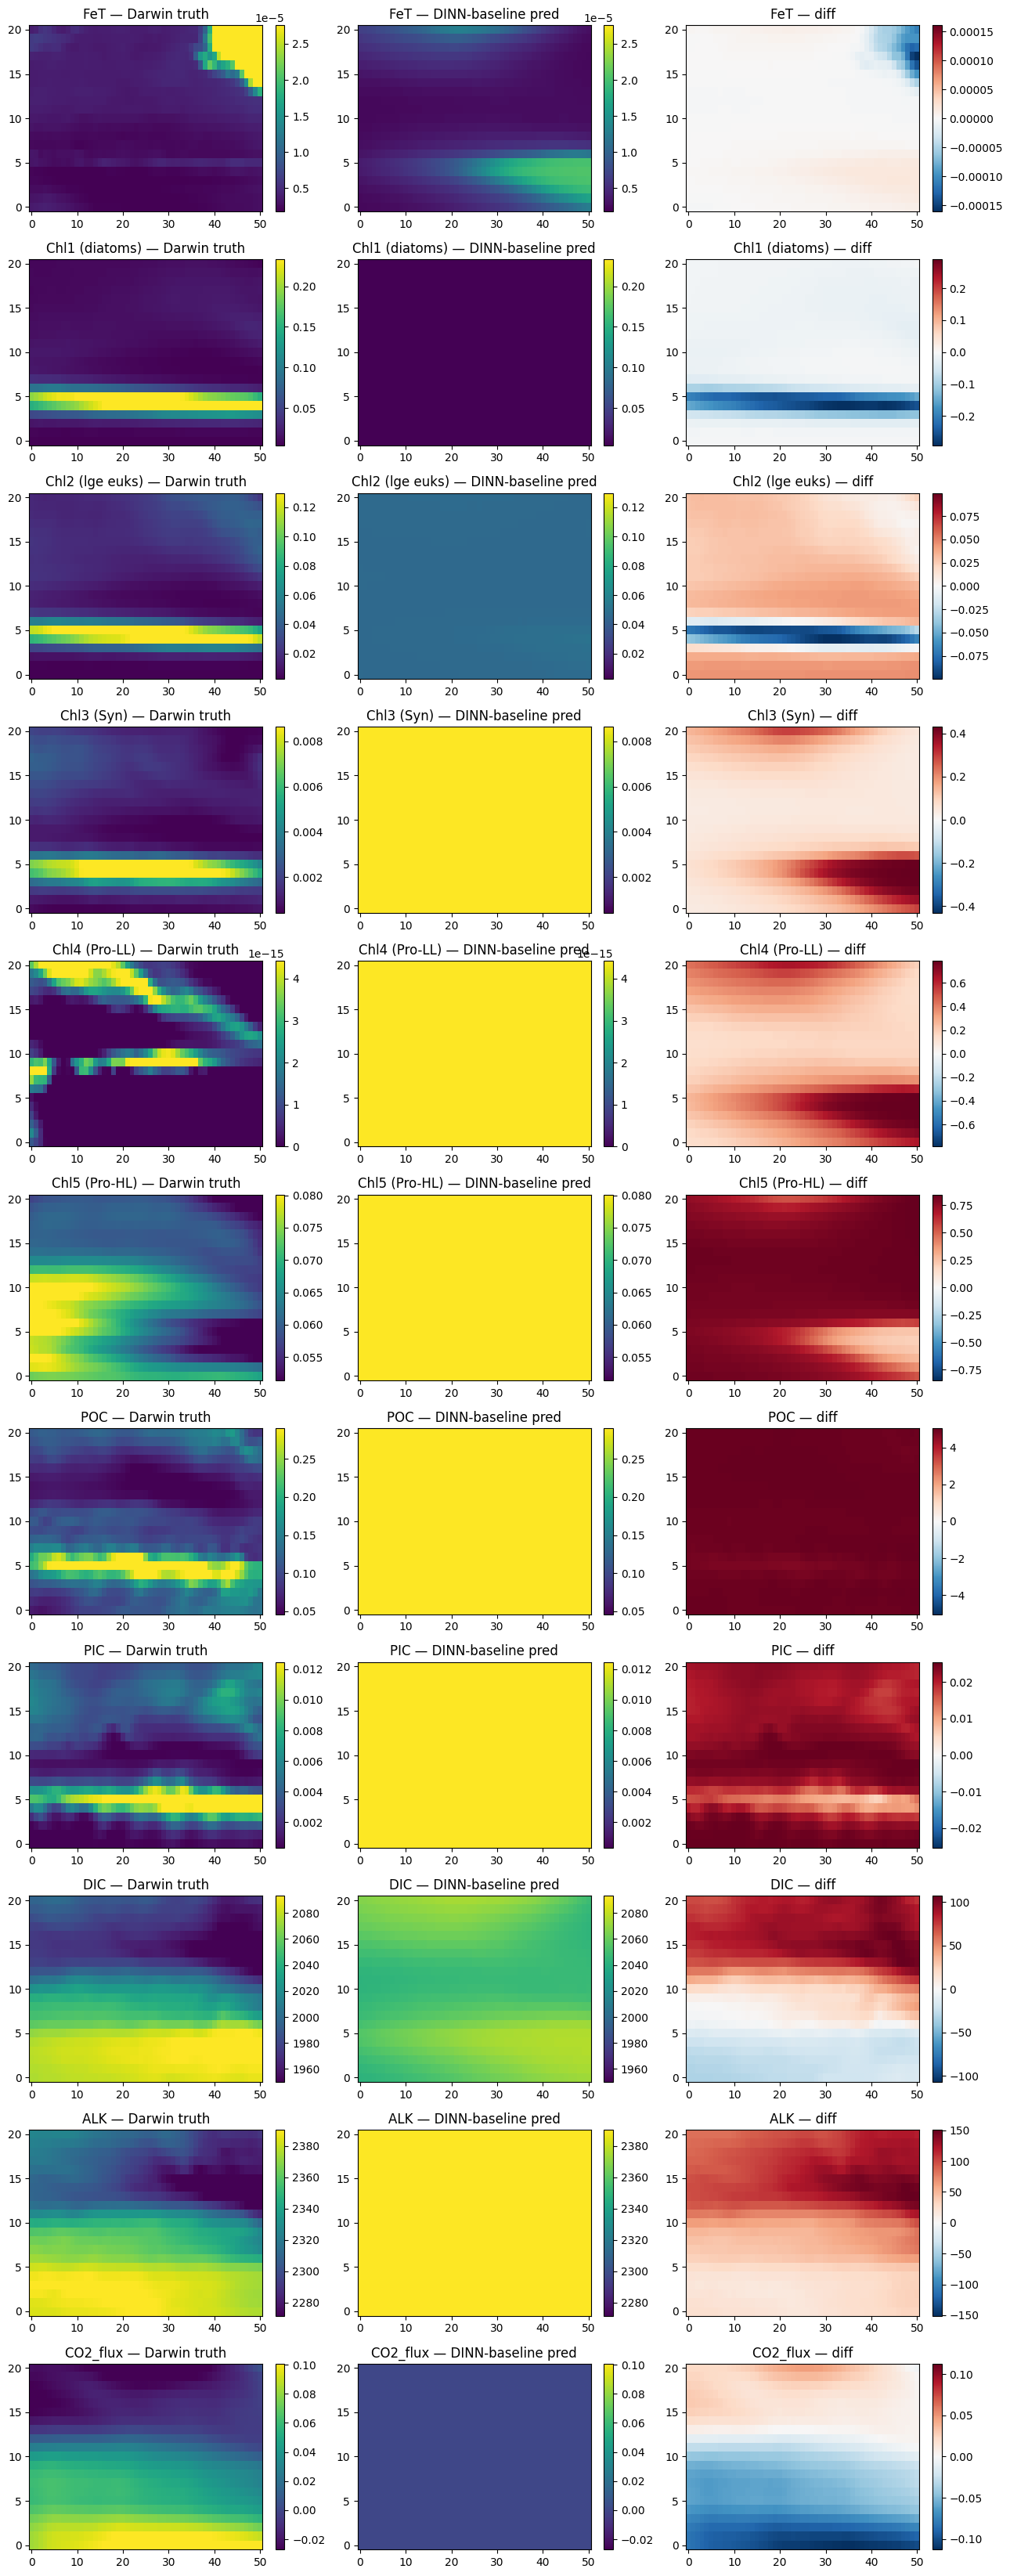

In [6]:
tracers_to_plot = [
    ("FeT",  fet_binned,                 r_baseline["dfe_final"]),
    ("Chl1 (diatoms)",  chl_per_pft["Chl1"], r_baseline["p_diatom_final"]),
    ("Chl2 (lge euks)", chl_per_pft["Chl2"], r_baseline["p_lge_final"]),
    ("Chl3 (Syn)",      chl_per_pft["Chl3"], r_baseline["p_syn_final"]),
    ("Chl4 (Pro-LL)",   chl_per_pft["Chl4"], r_baseline["p_proLL_final"]),
    ("Chl5 (Pro-HL)",   chl_per_pft["Chl5"], r_baseline["p_proHL_final"]),
    ("POC", poc_binned, r_baseline["poc_final"]),
    ("PIC", pic_binned, r_baseline["pic_final"]),
    ("DIC", dic_binned, r_baseline["dic_final"]),
    ("ALK", alk_binned, r_baseline["alk_final"]),
    ("CO2_flux", co2_flux_obs, r_baseline["co2_flux_final"]),
]

fig, axes = plt.subplots(len(tracers_to_plot), 3, figsize=(13, 3 * len(tracers_to_plot)))
for row, (name, target, pred) in enumerate(tracers_to_plot):
    target_plot = np.where(ocean_mask, target, np.nan)
    pred_plot = np.where(ocean_mask, pred, np.nan)
    diff = pred_plot - target_plot
    vmin, vmax = np.nanpercentile(target_plot, [5, 95])
    im0 = axes[row, 0].imshow(target_plot, vmin=vmin, vmax=vmax, cmap="viridis", origin="lower", aspect="auto")
    axes[row, 0].set_title(f"{name} — Darwin truth")
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.04)
    im1 = axes[row, 1].imshow(pred_plot, vmin=vmin, vmax=vmax, cmap="viridis", origin="lower", aspect="auto")
    axes[row, 1].set_title(f"{name} — DINN-baseline pred")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.04)
    dmax = np.nanmax(np.abs(diff)) or 1.0
    im2 = axes[row, 2].imshow(diff, vmin=-dmax, vmax=dmax, cmap="RdBu_r", origin="lower", aspect="auto")
    axes[row, 2].set_title(f"{name} — diff")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.04)
plt.tight_layout()
plt.show()


## 6. Interpretation — did per-PFT K_Fe restore the iron pair?

Read the goal-check table in §4. The key question is alpfe: nb23 had it at 0.891 off Carroll (Loose, regressed from v2.0's 0.011). If v2.2.1 brings alpfe back into Calibration-grade, the shared-K_FE hypothesis is confirmed and the path forward is clear (per-PFT mortality + half-sat for nitrogen / phosphate / silicate as v2.2.2 candidates).

If alpfe stays Loose: per-PFT K_FE wasn't the bottleneck for alpfe identifiability. Then the search shifts to per-PFT mortality (`M_LIN`, `M_QUAD`) or per-PFT iron quota (`Q_FE`).
